In [1]:
using DrWatson

@quickactivate "ReservoirInverseDesign"

projectname()

"ReservoirInverseDesign"

In [2]:
using CairoMakie

In [3]:
using DifferentialEquations
using LinearAlgebra
using Random
using Statistics
using Distributed

using Lux
using Metal
# using LuxCUDA
using LuxCore
using NeuralOperators
using Optimisers
using Optimization
using OptimizationMultistartOptimization
using OptimizationMetaheuristics
using OptimizationBBO
using OptimizationOptimJL
using Zygote
using Enzyme
using Reactant

using JLD2


In [4]:
Threads.nthreads()

8

In [5]:
dev = reactant_device(; force=true)

(::ReactantDevice{Missing, Missing, Missing, Missing, Union{}}) (generic function with 1 method)

In [50]:
include(srcdir("kdV_Reservoir_Surrogate.jl"))
include(srcdir("experiments/Reservoir_1.jl"));

In [7]:
fno_train = false

false

In [8]:
rng = Random.MersenneTwister(42);

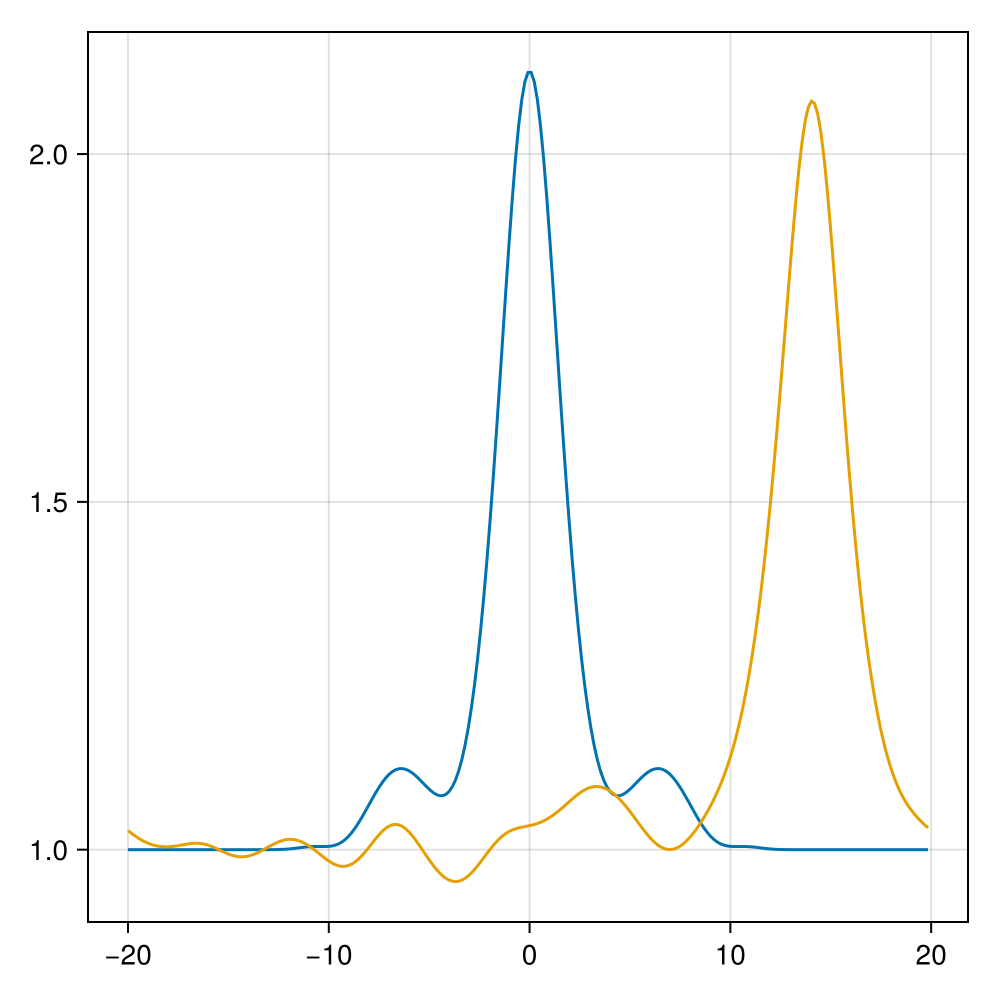

In [9]:
θ = [0.05, 0.20, 0.07, 0.24, 0.433, 0.500,20]

u01 = encode_initial_condition_7(X_BITS[1], x, θ, p_soliton)

prob_01 = ODEProblem(kdv_fd!, u01, (0.0, 10.0), p_reservoir)

sol = solve(prob_01, AutoVern7(RadauIIA5()));

u_final = sol.u[end]

fig = CairoMakie.Figure(size = (500,500))
ax = Axis(fig[1,1])

lines!(ax,x,u01)
lines!(ax,x,u_final)

fig

In [10]:
# -----------------------
# load training data
# -----------------------

data = load(datadir("exp_raw/kdV/kdV_train_500_100.jld2"))

X_train = data["X_train"]
Y_train = data["Y_train"]

X_test = data["X_test"]
Y_test = data["Y_test"]

meta_train = data["meta_train"]
meta_test = data["meta_test"];

In [11]:
fno_train = true

true

Training FNO...


I0000 00:00:1775303073.132461 3242974 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.
┌ Info: epoch = 50, loss = 0.018732997
└ @ Main /Users/boothh/Documents/ReservoirInverseDesign/src/kdV_Reservoir_Surrogate.jl:322
┌ Info: epoch = 100, loss = 0.016315164
└ @ Main /Users/boothh/Documents/ReservoirInverseDesign/src/kdV_Reservoir_Surrogate.jl:322


┌ Info: epoch = 150, loss = 0.013573294
└ @ Main /Users/boothh/Documents/ReservoirInverseDesign/src/kdV_Reservoir_Surrogate.jl:322
┌ Info: epoch = 200, loss = 0.010731545
└ @ Main /Users/boothh/Documents/ReservoirInverseDesign/src/kdV_Reservoir_Surrogate.jl:322


┌ Info: epoch = 250, loss = 0.007967234
└ @ Main /Users/boothh/Documents/ReservoirInverseDesign/src/kdV_Reservoir_Surrogate.jl:322
┌ Info: epoch = 300, loss = 0.0058377157
└ @ Main /Users/boothh/Documents/ReservoirInverseDesign/src/kdV_Reservoir_Surrogate.jl:322


┌ Info: epoch = 350, loss = 0.00441572
└ @ Main /Users/boothh/Documents/ReservoirInverseDesign/src/kdV_Reservoir_Surrogate.jl:322
┌ Info: epoch = 400, loss = 0.0034670583
└ @ Main /Users/boothh/Documents/ReservoirInverseDesign/src/kdV_Reservoir_Surrogate.jl:322


...

┌ Info: epoch = 650, loss = 0.0019261552
└ @ Main /Users/boothh/Documents/ReservoirInverseDesign/src/kdV_Reservoir_Surrogate.jl:322
┌ Info: epoch = 700, loss = 0.0016587854
└ @ Main /Users/boothh/Documents/ReservoirInverseDesign/src/kdV_Reservoir_Surrogate.jl:322


┌ Info: epoch = 750, loss = 0.0014964379
└ @ Main /Users/boothh/Documents/ReservoirInverseDesign/src/kdV_Reservoir_Surrogate.jl:322
┌ Info: epoch = 800, loss = 0.0013743548
└ @ Main /Users/boothh/Documents/ReservoirInverseDesign/src/kdV_Reservoir_Surrogate.jl:322


┌ Info: epoch = 850, loss = 0.0012776305
└ @ Main /Users/boothh/Documents/ReservoirInverseDesign/src/kdV_Reservoir_Surrogate.jl:322
┌ Info: epoch = 900, loss = 0.0012281889
└ @ Main /Users/boothh/Documents/ReservoirInverseDesign/src/kdV_Reservoir_Surrogate.jl:322


┌ Info: epoch = 950, loss = 0.0011458675
└ @ Main /Users/boothh/Documents/ReservoirInverseDesign/src/kdV_Reservoir_Surrogate.jl:322
┌ Info: epoch = 1000, loss = 0.0010923442
└ @ Main /Users/boothh/Documents/ReservoirInverseDesign/src/kdV_Reservoir_Surrogate.jl:322


Final training loss = 0.0010923442

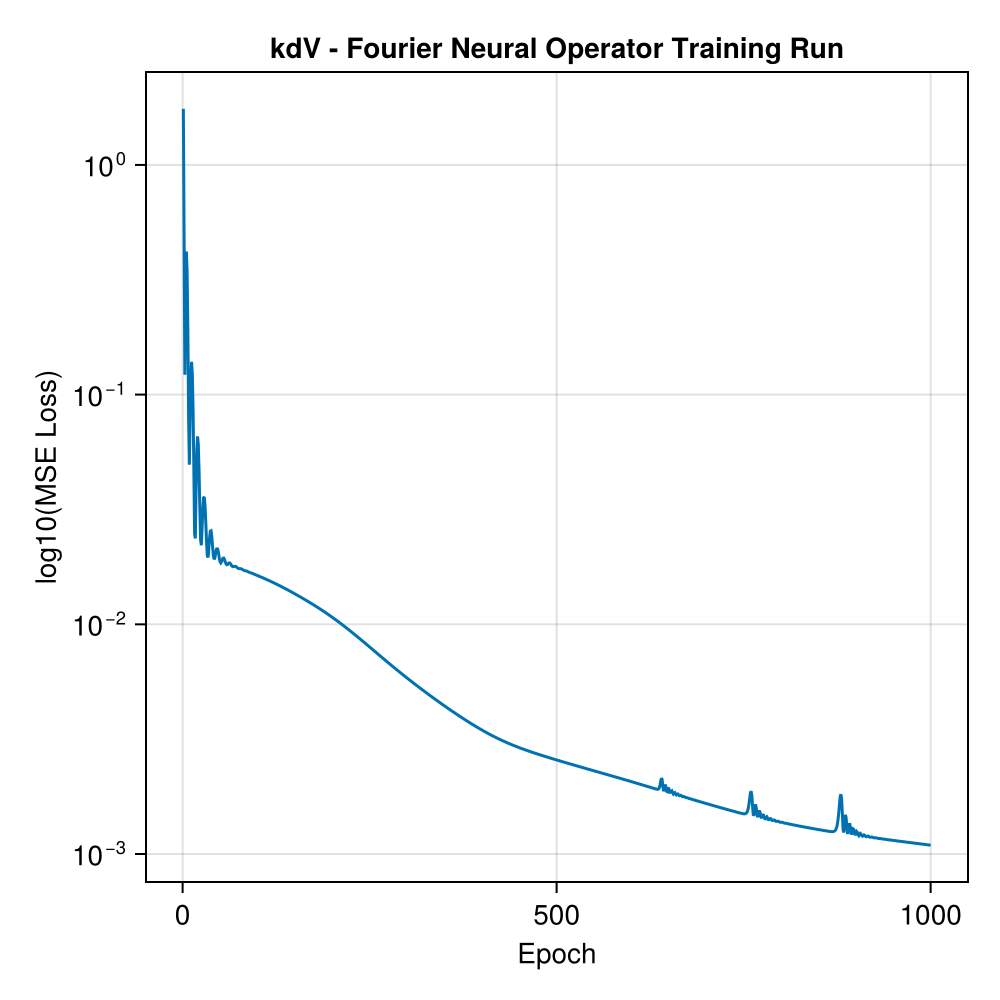

In [12]:
 if fno_train

    # ------------------------
    # Train FNO surrogate
    # ------------------------

    println("Training FNO...")

    fno_width = 32
    fno_modes = 16
    training_epochs = 1000

    fno, ps, st, losses = train_fno(
        X_train,
        Y_train;
        width = fno_width,
        modes = fno_modes,
        epochs = training_epochs ,
        lr = 3f-3,
        rng = rng,
        xdev = dev,
    )

    println("Final training loss = ", losses[end])

    ps_cpu = ps |> cpu_device()
    st_cpu = st |> cpu_device()

    fno_data_dict = Dict()
    fno_data_dict["width"] = fno_width
    fno_data_dict["modes"] = fno_modes
    fno_data_dict["ps"] = ps_cpu
    fno_data_dict["st"] = st_cpu
    fno_data_dict["losses"] = losses

    save(datadir("exp_raw","fno_trained_TD500_TE100_Epochs" * string(training_epochs) * ".jld2"),fno_data_dict)

 else

    println("Loading FNO...")

    fno_model = load(datadir("exp_raw","fno_trained_TD500_TE100_Epochs500.jld2"))

    fno_width = fno_model["width"]
    fno_modes = fno_model["modes"]

    fno = FourierNeuralOperator(
        gelu;
        chs = (1, fno_width, fno_width, 2fno_width, 1),
        modes = (fno_modes,),
    )

    ps_cpu = fno_model["ps"]
    st_cpu = fno_model["st"]
    losses = fno_model["losses"]
 end

 fig = CairoMakie.Figure(size = (500,500))
 ax = Axis(fig[1,1],xlabel = "Epoch",ylabel = "log10(MSE Loss)", yscale = log10,title = "kdV - Fourier Neural Operator Training Run")
 
 lines!(ax,losses)
 
 fig

In [18]:
# ------------------------
# Inverse design, surrogate model
#
# ------------------------

n_readouts = 4
θ0 = [0.05, 0.20, 0.07, 0.24, 0.433, 0.500, 20.0]
xreadout0 = collect(range(-8.0, 8.0, length=n_readouts))

println("Optimizing theta + readout positions...")

sol = optimize_theta_and_readouts(
    fno,
    ps_cpu,
    st_cpu,
    θ0,
    xreadout0,
    lb_theta,
    ub_theta,
    x,
    p_soliton;
    λ_rep = 1f-3,
    sigma = 1.5 * dx,
    nstarts = 500,
)

zbest = Array(sol.u)
θ_best = zbest[1:7]
xread_best = zbest[8:end]

println("θ_best = ", θ_best)
println("xread_best = ", xread_best)

Optimizing theta + readout positions...


θ_best = 

[0.009999999776495318, 0.349999994039526, 0.009999999776497955, 0.34999999403952764, 0.3914092882479985, 0.20352909387453583, 26.777743575211794]
xread_best = [17.60628881944405, -3.54343087631088, 15.807728430729124, 14.003705288956136]


In [19]:
# ------------------------
# Surrogate score
# ------------------------

R_hat = surrogate_readout_matrix(
    fno, ps_cpu, st_cpu, θ_best, xread_best, x, p_soliton;
    sigma = 1.5 * dx,
)
println("Surrogate R = ")
display(R_hat)
println("Surrogate separability score = ", separability_score(R_hat))


# ------------------------
# Ground-truth PDE validation
# ------------------------

println("Validating on the full PDE...")

R_true = true_readout_matrix(
    θ_best,
    xread_best,
    x,
    prob,
    t_end,
    p_soliton;
    sigma = 1.5 * dx,
    reltol = 1e-10,
    abstol = 1e-10,
)

println("True R = ")
display(R_true)
println("True separability score = ", separability_score(R_true))

if size(R_true, 1) == size(R_true, 2)
    surrogate_best_fitness = abs(det(R_true))
    println("True |det(R)| = ", surrogate_best_fitness)
else
    surrogate_best_fitness = det(R_true * R_true')
    println("True det(RR') = ", surrogate_best_fitness)
end

4×4 Matrix{Float64}:
 0.985726  0.996056  1.27575  2.00224
 1.76112   1.11776   2.48894  1.47553
 1.70286   0.901496  2.17165  1.96103
 3.11341   1.0147    1.79553  1.05244

Surrogate R = 
Surrogate separability score = 0.593155828051606
Validating on the full PDE...


True R = 

4×4 Matrix{Float64}:
 1.0699   1.00196   1.33248  1.94027
 1.65931  1.12093   2.56404  1.49945
 1.67862  0.898496  2.18611  1.9493
 2.68256  1.03264   1.61083  1.32876


True separability score = 0.3932768679660831
True |det(R)| = 1.4818276034105873


In [25]:
n_fno_training_samples = Int(size(X_train,3) / 4)

500

In [15]:
if run_bbo_comparison

    n_fno_training_samples = Int(size(X_train,3) / 4)

    alg_names = ["Adaptive_Differential_Evolution","Exponential_NES","Generating_Set_Search"]
    alg_methods = [BBO_adaptive_de_rand_1_bin_radiuslimited(),BBO_xnes(),BBO_generating_set_search()]

    alg_best_determinants = []
    alg_sol = []

    for (alg_name,alg) in zip(alg_names,alg_methods)

        println("Optimizing theta + readout positions for " * alg_name * "...")

        meta_alg = false

        sol_opt = optimize_theta_and_readouts_BBO(
            prob,
            t_end,
            θ0,
            xreadout0,
            lb_theta,
            ub_theta,
            x,
            p_soliton;
            MaxFuncEvals = n_fno_training_samples,
            λ_rep = 1f-3,
            sigma = 1.5 * dx,
            alg = alg,
            meta_alg = meta_alg)

        zbest = Array(sol_opt.u)
        θ_best = zbest[1:7]
        xread_best = zbest[8:end]

        R_true = true_readout_matrix(
                        θ_best,
                        xread_best,
                        x,
                        prob,
                        t_end,
                        p_soliton;
                        sigma = 1.5 * dx)

        
        println("separability score = ", separability_score(R_true))

        if size(R_true, 1) == size(R_true, 2)
            fitness = abs(det(R_true))
            println("True |det(R)| = ", fitness)
        else
            fitness = det(R_true * R_true')
            println("True det(RR') = ", fitness)
        end

        push!(alg_best_determinants,fitness)
        push!(alg_sol,sol_opt)

    end
else
    



In [37]:
alg_summary = load(datadir("exp_raw/kdV_TestBBO_500_MT_100.jld2"))["alg_summary"]

alg_best_determinants = map(y->map(x->x[3],y),alg_summary)

alg_best_theta = map(y->map(x->x[1],y),alg_summary)

alg_best_readouts = map(y->map(x->x[2],y),alg_summary)

argmax.(alg_best_determinants)

3-element Vector{Int64}:
 61
 57
 46

In [38]:
alg_best_theta[3][46]

7-element Vector{Float64}:
  0.349999999999767
  0.16716846158670517
  0.01000004584116044
  0.3499999990274568
  0.2000000001899296
  0.20000003298728183
 29.999958408631716

In [40]:
alg_best_readouts[3][46]

4-element Vector{Float64}:
 15.733238143033148
 18.63503983642795
 16.955436578839432
 13.660811189856119

In [51]:
θ0 = alg_best_theta[3][46]
xreadout0 = alg_best_readouts[3][46]

println("Optimizing theta + readout positions...")

sol = optimize_theta_and_readouts(
    fno,
    ps_cpu,
    st_cpu,
    θ0,
    xreadout0,
    lb_theta,
    ub_theta,
    x,
    p_soliton;
    λ_rep = 1f-3,
    sigma = 1.5 * dx
)

zbest = Array(sol.u)
θ_best = zbest[1:7]
xread_best = zbest[8:end]

In [49]:
# ------------------------
# Surrogate score
# ------------------------

R_hat = surrogate_readout_matrix(
    fno, ps_cpu, st_cpu, θ_best, xread_best, x, p_soliton;
    sigma = 1.5 * dx,
)
println("Surrogate R = ")
display(R_hat)
println("Surrogate separability score = ", separability_score(R_hat))


# ------------------------
# Ground-truth PDE validation
# ------------------------

println("Validating on the full PDE...")

R_true = true_readout_matrix(
    θ_best,
    xread_best,
    x,
    prob,
    t_end,
    p_soliton;
    sigma = 1.5 * dx,
    reltol = 1e-10,
    abstol = 1e-10,
)

println("True R = ")
display(R_true)
println("True separability score = ", separability_score(R_true))

if size(R_true, 1) == size(R_true, 2)
    surrogate_best_fitness = abs(det(R_true))
    println("True |det(R)| = ", surrogate_best_fitness)
else
    surrogate_best_fitness = det(R_true * R_true')
    println("True det(RR') = ", surrogate_best_fitness)
end

retcode: Default
u: 11-element Vector{Float32}:
  0.265
  0.095
  0.095
  0.095
  0.72499996
  0.72499996
 15.0
  9.882355
  9.882355
  9.882355
  9.882355

In [46]:
# alg_comparison_det = vcat([surrogate_best_fitness],alg_best_determinants)
# alg_comparison_names = vcat(["NO_Surrogate + gradient_based"],alg_names)

# fig = CairoMakie.Figure(size = (500,500))

# ax = Axis(fig[1,1],xlabel = "Search algorithm",ylabel = "True |det(R)|",title = "kdV RID: search comparison w/ 2500 function evals")

# scatter!(ax,[i for i in 1:length(alg_comparison_det)],alg_comparison_det)

# ax.xticks = (1:length(alg_comparison_det),alg_comparison_names)
# ax.xticklabelrotation = 45.

# fig